In [8]:
import requests
import json
from pathlib import Path

# Request more jobs: increase count. If the API has a hard limit, it will return the max available.
count = 100  # increase this if the API supports more
url = f"https://jobicy.com/api/v2/remote-jobs?count={count}&geo=usa&industry=dev"
headers = {"User-Agent": "Mozilla/5.0"}  # helps avoid 403/401 errors

print(f"Fetching jobs from: {url}")
r = requests.get(url, headers=headers, timeout=15)
print(f"HTTP {r.status_code}")
try:
    data = r.json()
except Exception as e:
    print("Failed to decode JSON:", e)
    data = {}

out_path = Path("jobs.json")
with out_path.open("w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

jobs = []
if isinstance(data, dict):
    # try common keys that APIs use to hold items
    for k in ("jobs", "data", "results", "items"):
        if k in data and isinstance(data[k], list):
            jobs = data[k]
            break
    # fallback: if top-level is list-like, use it
    if not jobs:
        # look for any list values and pick the largest
        lists = [(k, v) for k, v in data.items() if isinstance(v, list)]
        if lists:
            # pick the longest list
            jobs = max(lists, key=lambda kv: len(kv[1]))[1]
elif isinstance(data, list):
    jobs = data

print(f"Saved raw response to {out_path}. Parsed {len(jobs)} jobs (may be 0 if structure differs).")
for job in jobs[:20]:
    title = job.get('jobTitle') or job.get('title') or job.get('name')
    company = job.get('companyName') or job.get('company') or job.get('org')
    geo = job.get('jobGeo') or job.get('location') or job.get('job_location')
    print(f"{title} at {company} — {geo}")

Fetching jobs from: https://jobicy.com/api/v2/remote-jobs?count=100&geo=usa&industry=dev
HTTP 200
Saved raw response to jobs.json. Parsed 70 jobs (may be 0 if structure differs).
Software Engineer, Link at Stripe — USA
Software Engineer II at Microsoft — USA
Principal Security Engineer (IC4) at Oracle — USA
Software Engineer, Product at Meta — USA
Software Engineer, Android at Meta — USA
Supplier Quality Engineer at Capgemini — USA
Laravel and React Tech Lead at Kubikware — USA
Sr Product Developer at Claritev — USA
Sr. Cyber Infrastructure Engineer at NBCUniversal — USA
Senior Cloud Software Developer (Kotlin) at Intelerad — USA
Director, Identity Governance &amp;#038; Directory Services at NBCUniversal — USA
Engineer, PKI at NBCUniversal — USA
Senior Solutions Engineer, Commercial (AMER) at ClickUp — USA
Staff Cyber Security Engineer at NBCUniversal — USA
IAM and Security Services Architect at NBCUniversal — USA
Senior Director, Software Engineering (Machine Learning) at Affirm — USA

Loaded 70 jobs for EDA


,title,company,location,type,posted
0,"Software Engineer, Link",Stripe,USA,[Full-Time],None
1,Software Engineer II,Microsoft,USA,[Full-Time],None
2,Principal Security Engineer (IC4),Oracle,USA,[Full-Time],None
3,"Software Engineer, Product",Meta,USA,[Full-Time],None
4,"Software Engineer, Android",Meta,USA,[Full-Time],None
5,Supplier Quality Engineer,Capgemini,USA,[Full-Time],None
6,Laravel and React Tech Lead,Kubikware,USA,[Full-Time],None
7,Sr Product Developer,Claritev,USA,[Full-Time],None
8,Sr. Cyber Infrastructure Engineer,NBCUniversal,USA,[Full-Time],None
9,Senior Cloud Software Developer (Kotlin),Intelerad,USA,[Full-Time],None


C:\Users\thoma\AppData\Local\Temp\ipykernel_39412\1441874921.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_counts.values, y=loc_counts.index, palette='viridis')


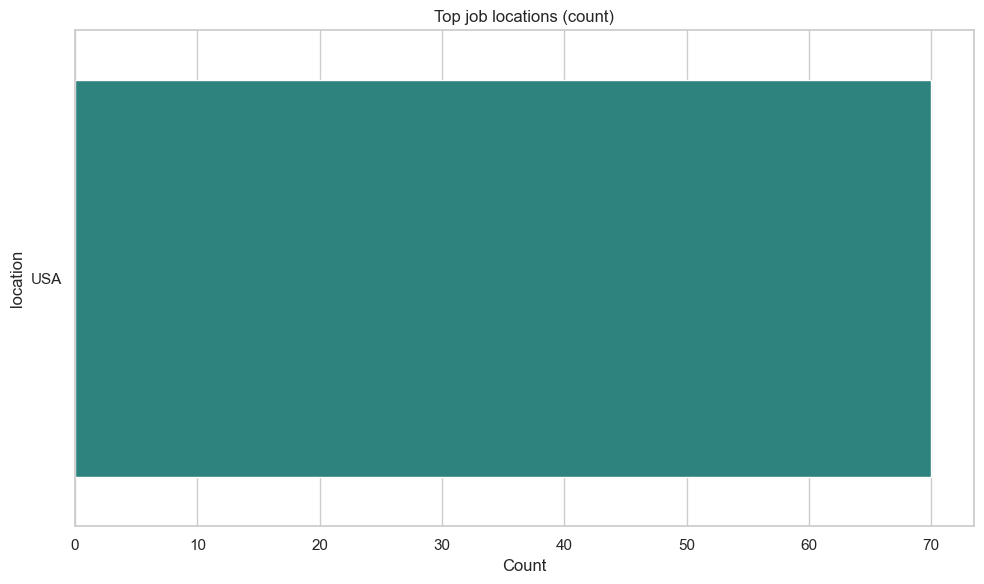

C:\Users\thoma\AppData\Local\Temp\ipykernel_39412\1441874921.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comp_counts.values, y=comp_counts.index, palette='magma')


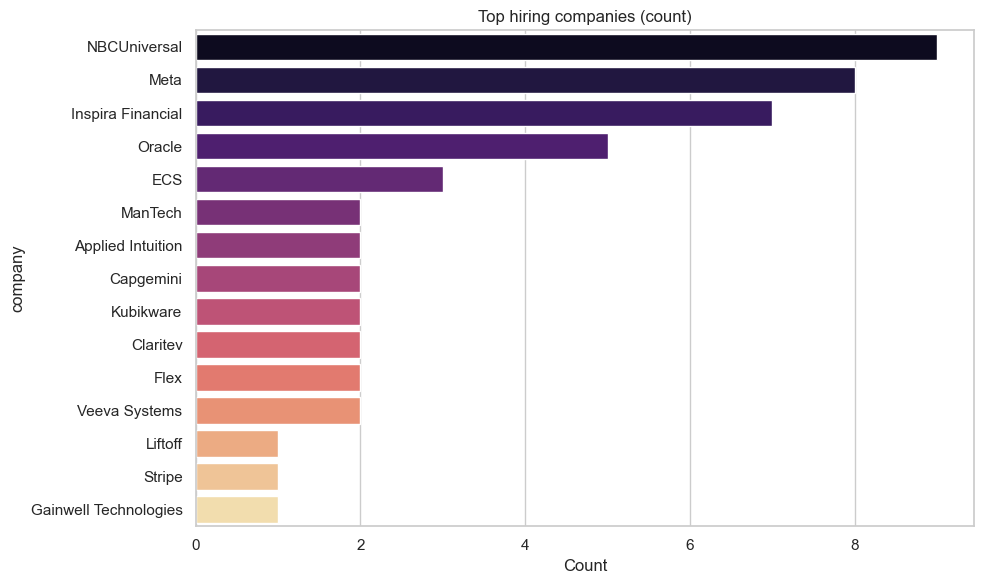

C:\Users\thoma\AppData\Local\Temp\ipykernel_39412\1441874921.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='cool')


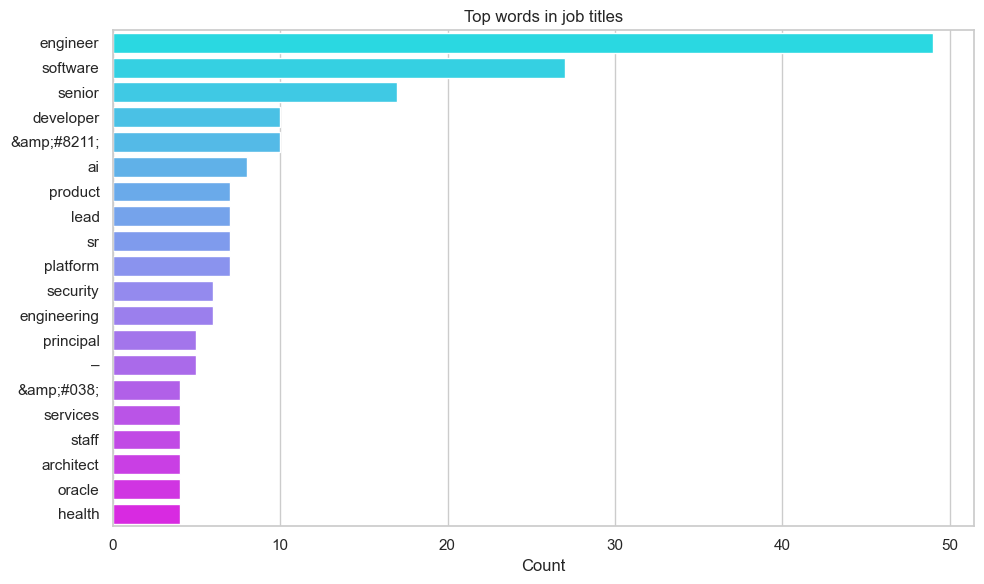

In [ ]:
# Simple EDA on jobs.json
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set(style="whitegrid")
data_path = Path('jobs.json')
if not data_path.exists():
    raise FileNotFoundError('jobs.json not found - run the fetch cell first')

with data_path.open('r', encoding='utf-8') as f:
    raw = json.load(f)

# Extract job list similar to fetch cell logic
jobs = []
if isinstance(raw, dict):
    for k in ('jobs','data','results','items'):
        if k in raw and isinstance(raw[k], list):
            jobs = raw[k]
            break
    if not jobs:
        lists = [(k,v) for k,v in raw.items() if isinstance(v, list)]
        if lists:
            jobs = max(lists, key=lambda kv: len(kv[1]))[1]





C:\Users\thoma\AppData\Local\Temp\ipykernel_39412\4245711878.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lvl_counts.values, y=lvl_counts.index, palette='coolwarm')


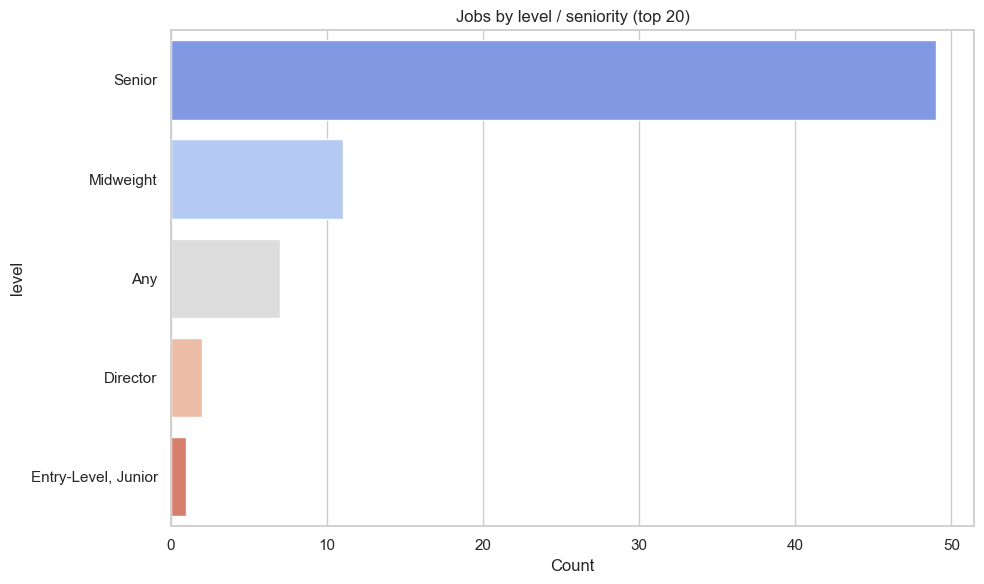

In [12]:
# 3) One by job level
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
p = Path('jobs.json')
with p.open('r', encoding='utf-8') as f:
    raw = json.load(f)
jobs = raw if isinstance(raw, list) else next((raw.get(k) for k in ('jobs','data','results','items') if isinstance(raw.get(k), list)), [])
rows = []
for j in jobs:
    level = j.get('seniority') or j.get('jobLevel') or j.get('level') or j.get('experience_level')
    rows.append({'level': level or 'Unknown'})
df_lvl = pd.DataFrame(rows)
lvl_counts = df_lvl['level'].value_counts().nlargest(20)
plt.figure(figsize=(10,6))
sns.barplot(x=lvl_counts.values, y=lvl_counts.index, palette='coolwarm')
plt.title('Jobs by level / seniority (top 20)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


Text descriptions available: 70 / 70


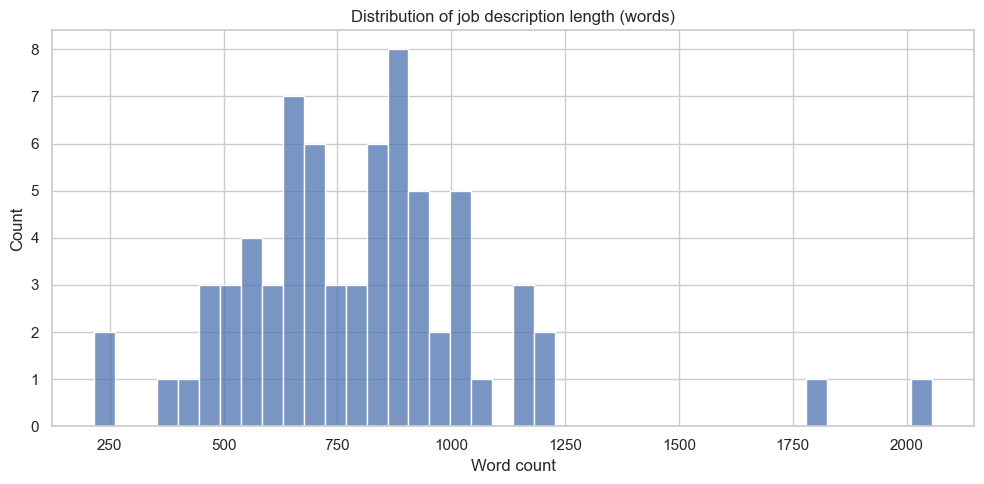

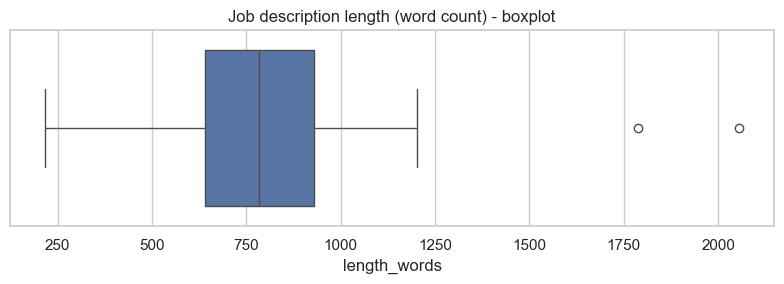

Loaded 70 jobs for EDA


,title,company,location,type,posted
0,"Software Engineer, Link",Stripe,USA,[Full-Time],None
1,Software Engineer II,Microsoft,USA,[Full-Time],None
2,Principal Security Engineer (IC4),Oracle,USA,[Full-Time],None
3,"Software Engineer, Product",Meta,USA,[Full-Time],None
4,"Software Engineer, Android",Meta,USA,[Full-Time],None
5,Supplier Quality Engineer,Capgemini,USA,[Full-Time],None
6,Laravel and React Tech Lead,Kubikware,USA,[Full-Time],None
7,Sr Product Developer,Claritev,USA,[Full-Time],None
8,Sr. Cyber Infrastructure Engineer,NBCUniversal,USA,[Full-Time],None
9,Senior Cloud Software Developer (Kotlin),Intelerad,USA,[Full-Time],None


C:\Users\thoma\AppData\Local\Temp\ipykernel_39412\941756363.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_counts.values, y=loc_counts.index, palette='viridis')


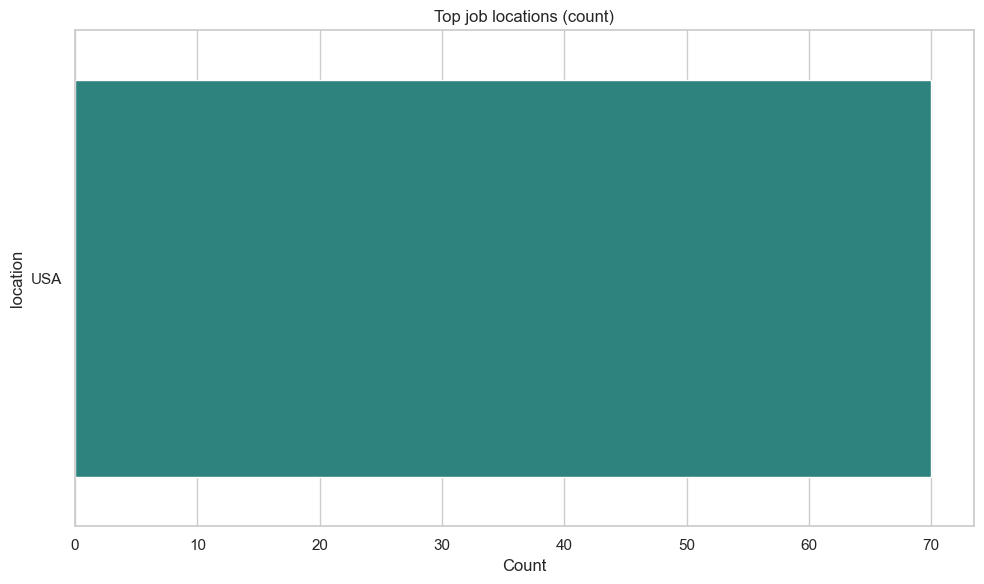

C:\Users\thoma\AppData\Local\Temp\ipykernel_39412\941756363.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comp_counts.values, y=comp_counts.index, palette='magma')


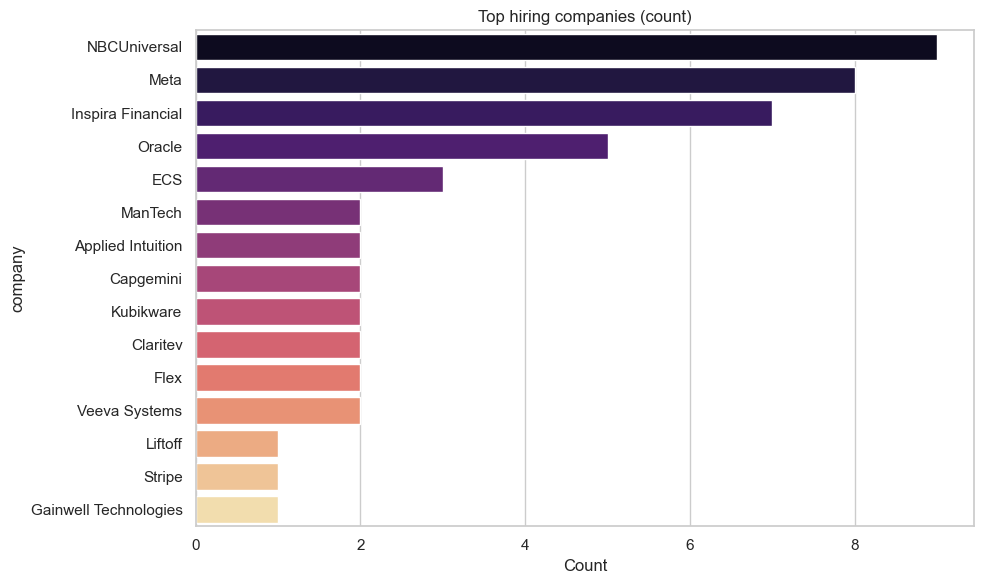

C:\Users\thoma\AppData\Local\Temp\ipykernel_39412\941756363.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='cool')


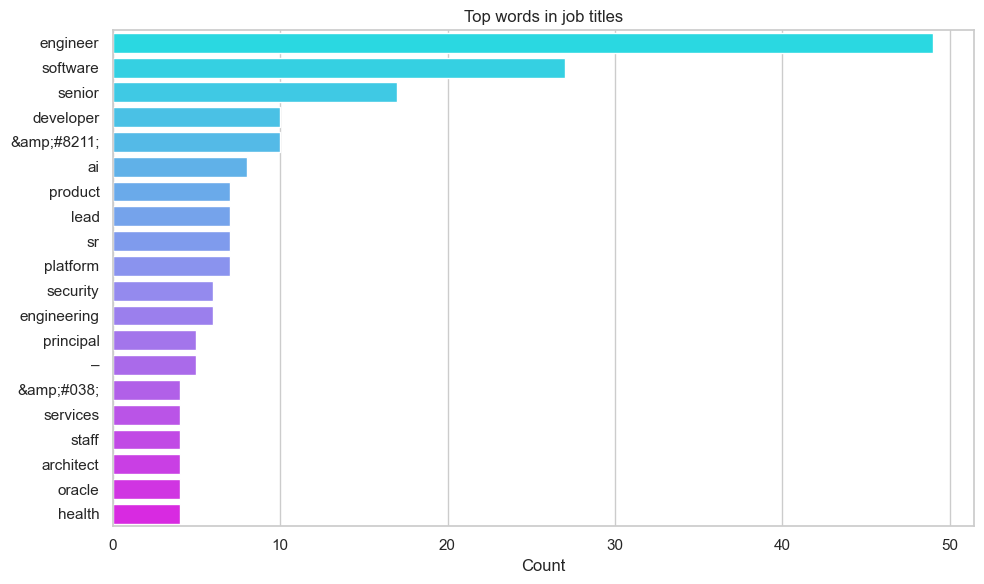

In [13]:
# 4) Length of job description
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
p = Path('jobs.json')
with p.open('r', encoding='utf-8') as f:
    raw = json.load(f)
jobs = raw if isinstance(raw, list) else next((raw.get(k) for k in ('jobs','data','results','items') if isinstance(raw.get(k), list)), [])
rows = []
for j in jobs:
    desc = j.get('description') or j.get('jobDescription') or j.get('summary') or j.get('details') or ''
    length_words = len(str(desc).split()) if desc else 0
    rows.append({'desc': desc, 'length_words': length_words})
df_desc = pd.DataFrame(rows)
print(f'Text descriptions available: {df_desc['length_words'].gt(0).sum()} / {len(df_desc)}')
# Histogram
plt.figure(figsize=(10,5))
sns.histplot(df_desc['length_words'].where(df_desc['length_words']>0).dropna(), bins=40, kde=False)
plt.title('Distribution of job description length (words)')
plt.xlabel('Word count')
plt.tight_layout()
plt.show()
# Boxplot to show spread
plt.figure(figsize=(8,3))
sns.boxplot(x=df_desc['length_words'].where(df_desc['length_words']>0).dropna(), orient='h')
plt.title('Job description length (word count) - boxplot')
plt.tight_layout()
plt.show()

print(f'Loaded {len(jobs)} jobs for EDA')
if not jobs:
    print('No job items found in jobs.json; inspect the raw file to adapt parsing')

# Normalize into DataFrame with common fields
rows = []
for j in jobs:
    rows.append({
        'title': j.get('jobTitle') or j.get('title') or j.get('name'),
        'company': j.get('companyName') or j.get('company') or j.get('org'),
        'location': j.get('jobGeo') or j.get('location') or j.get('job_location'),
        'type': j.get('jobType') or j.get('type'),
        'posted': j.get('postedAt') or j.get('date') or j.get('created_at'),
    })
df = pd.DataFrame(rows)
display(df.head(10))

# Top locations
loc_counts = df['location'].fillna('Unknown').value_counts().nlargest(15)
plt.figure(figsize=(10,6))
sns.barplot(x=loc_counts.values, y=loc_counts.index, palette='viridis')
plt.title('Top job locations (count)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Top companies
comp_counts = df['company'].fillna('Unknown').value_counts().nlargest(15)
plt.figure(figsize=(10,6))
sns.barplot(x=comp_counts.values, y=comp_counts.index, palette='magma')
plt.title('Top hiring companies (count)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Job title word frequency (simple)
title_tokens = []
for t in df['title'].dropna().astype(str):
    for w in t.split():
        title_tokens.append(w.strip('.,()/').lower())
top_words = Counter(title_tokens)
most_common = top_words.most_common(20)
words, counts = zip(*most_common) if most_common else ([], [])
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette='cool')
plt.title('Top words in job titles')
plt.xlabel('Count')
plt.tight_layout()
plt.show()